In [1]:
import numpy as np
from math import sqrt
from pprint import pprint
from sklearn import datasets, linear_model, metrics
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import cross_validate, KFold, cross_val_predict, train_test_split, cross_val_score
from sklearn import preprocessing
from sklearn.metrics import make_scorer, mean_squared_error
import matplotlib.pyplot as plt
from sklearn.linear_model import SGDRegressor

In [2]:
# Carga de datos.
#datos = datasets.load_boston()
datos = datasets.fetch_california_housing()
# print(datos)
X = datos.data
y = datos.target
print('Dimensiones de X: ', np.shape(X))
print(y)

Dimensiones de X:  (20640, 8)
[4.526 3.585 3.521 ... 0.923 0.847 0.894]


In [3]:
# # Métricas de evaluación.
metricas = {
  'MAE':  'neg_mean_absolute_error',
  'RMSE': make_scorer(lambda y, y_pred:
                      sqrt(metrics.mean_squared_error(y, y_pred)),
                      greater_is_better=False),
  'MAPE': make_scorer(lambda y, y_pred:
                      np.mean(np.abs((y - y_pred) / y)) * 100,
                      greater_is_better=False),
  'R2':   'r2',}

In [4]:
# 1) Partición de datos externa
X_training, X_testing, y_training, y_testing = train_test_split(X, y, test_size=0.2, random_state=42)
print(np.shape(X_training))
print(np.shape(X_testing))

(16512, 8)
(4128, 8)


In [5]:
# 2) Extracción de características, no nos hace falta en este caso
# 3) Selección de atributos
# 4) Estandarización de los datos de entrenamiento
standardizer = preprocessing.StandardScaler()
stdr_trained = standardizer.fit(X_training)
X_stdr = stdr_trained.transform(X_training)

In [22]:
# 5) Construcción del algoritmo de aprendizaje.
# reg = linear_model.LinearRegression(fit_intercept=True)
# reg = linear_model.SGDRegressor(fit_intercept=True, alpha=0.0001, penalty='l2', max_iter=100, learning_rate='optimal')
reg = linear_model.SGDRegressor(fit_intercept=True, alpha=0.0001)

In [23]:
# 5.1) Validación cruzada interna

# Extraer directamente resultados del error para cada bolsa, en lugar de las predicciones
cross_val_results = cross_validate(reg, X_stdr, y_training, 
                                    cv = KFold(n_splits=5, shuffle=True, random_state=42), scoring=metricas)
#print("cross_val_MAE:   %0.4f +/- %0.4f" % (-cross_val_results.mean(), cross_val_results.std()))
pprint(cross_val_results)

{'fit_time': array([0.01780748, 0.01491404, 0.01655769, 0.01129079, 0.03369188]),
 'score_time': array([0.0050807 , 0.00402904, 0.00619388, 0.00402474, 0.00990081]),
 'test_MAE': array([ -0.54447614, -81.41604689,  -0.55874829,  -0.56252575,
        -0.52830594]),
 'test_MAPE': array([  -32.11424592, -6224.42965063,   -34.55323927,   -35.08281242,
         -30.69342553]),
 'test_R2': array([ 6.04944050e-01, -1.11712003e+06,  5.76083511e-01,  5.20016364e-01,
        6.06827653e-01]),
 'test_RMSE': array([-7.38357921e-01, -1.21815562e+03, -7.51884224e-01, -8.04120683e-01,
       -7.13247697e-01])}


In [30]:
# reg = linear_model.LinearRegression(fit_intercept=True)
reg = linear_model.SGDRegressor(fit_intercept=True, alpha=0.0001)
# 5.2) Entrenamiento con todos los datos para obtener los coeficientes del modelo.
model = reg.fit(X_stdr, y_training) #aqui deberia incic desde 0, pero lo mejor seria instanciar un nuevo objeto por si acaso 

# Obtención de los coeficientes del modelo.
w = model.coef_
print('Model coeficients: \n', w)

# Obtención del término independiente del modelo.
w_0 = model.intercept_
print('\nTérmino independiente: ', w_0) #nos mide cuantos atributos son 0

Model coeficients: 
 [ 1.17912639  0.16406209 -0.82955071  0.80136809 -0.01616782 -0.3897415
 -0.38479122 -0.38838103]

Término independiente:  [2.05746397]


In [31]:
# ---- PREDICCIÓN ---- # 
#hasta ahora ya hemos ajustado los parametros necesarios 

In [35]:
# 6) Extracción de las características de test
# 7) Selección de los atributos de test 
# 8) Estandarización de las característiacs de test
X_test_stdr = stdr_trained.transform(X_testing) #IMPORTANTE SOLO TRANSFORM

In [36]:
# 9) Predicción del conjunto de test
y_pred_test = model.predict(X_test_stdr)

In [37]:
# Cálculo de las métricas de evaluación.
MAE = metrics.mean_absolute_error(y_testing, y_pred_test)
MSE = metrics.mean_squared_error(y_testing, y_pred_test)
RMSE = metrics.root_mean_squared_error(y_testing, y_pred_test)
MAPE = metrics.mean_absolute_percentage_error(y_testing, y_pred_test)
R2 = metrics.r2_score(y_testing, y_pred_test)

print('MAE:  %.4f' % MAE)
print('MSE: %.4f' % MSE)
print('RMSE: %.4f' % RMSE)
print('MAPE: %.4f' % MAPE)
print('R2:   %.4f' % R2)

MAE:  0.5446
MSE: 0.6599
RMSE: 0.8123
MAPE: 0.3195
R2:   0.4964


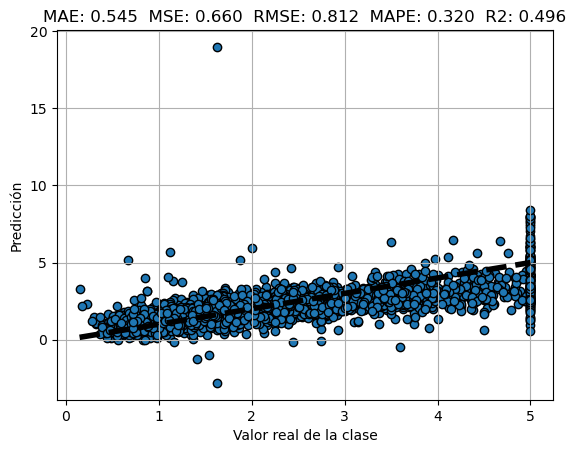

In [38]:
# Gráfica de realidad vs. predicción.
fig, ax = plt.subplots()
ax.scatter(y_testing, y_pred_test, edgecolors=(0, 0, 0))
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=4)
ax.set_xlabel('Valor real de la clase')
ax.set_ylabel('Predicción')
plt.title("MAE: %.3f  MSE: %.3f  RMSE: %.3f  MAPE: %.3f  R2: %.3f" %
          (MAE,MSE,RMSE,MAPE,R2))
plt.grid()
plt.show()

<!-- reg = linear_model.LinearRegression(fit_intercept=True) en el punto 5 -->
MAE:  0.5332
MSE: 0.5559
RMSE: 0.7456
MAPE: 0.3195
R2:   0.5758

reg = linear_model.SGDRegressor(fit_intercept=True, alpha=0.0001)
MAE:  0.5446
MSE: 0.6599
RMSE: 0.8123
MAPE: 0.3195
R2:   0.4964

el resultado es mas o menos el mismo usando ambos solvers en test
Habria que ver con mas calma que es lo que esta pasando en estos folds, pq sale cosas raras con la estandarizacion